<a href="https://colab.research.google.com/github/Arup3201/reint/blob/main/forecast_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REint: Forecast Analysis

In [13]:
import json
import requests
from datetime import datetime
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def load_dataset(output_file: str = "dataset.json") -> None:
    wind_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2024-01-01&settlementDateTo=2024-01-31&fuelType=WIND"
    forecast_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2024-01-01&publishDateTimeTo=2024-01-31"

    # Fetch actual wind data
    res = requests.get(wind_api)
    res.raise_for_status()
    actual_wind_data = res.json()

    # Fetch forecasted wind data
    res = requests.get(forecast_api)
    res.raise_for_status()
    forecasted_wind_data = res.json()

    # Build a lookup map from startTime -> list of forecast entries
    forecast_map = defaultdict(list)
    for entry in forecasted_wind_data:
        forecast_map[entry["startTime"]].append(entry)

    dataset = []
    for actual in actual_wind_data:
        start_time = actual["startTime"]
        forecasts = forecast_map.get(start_time)

        if forecasts:
            # One row per forecast matched to this actual startTime
            for forecast in forecasts:
                dataset.append({
                    "targetTime":  start_time,
                    "publishTime": forecast["publishTime"],
                    "actual":      actual["generation"],
                    "forecast":    forecast["generation"],
                })
        else:
            dataset.append({
                "targetTime":  start_time,
                "publishTime": None,
                "actual":      actual["generation"],
                "forecast":    None,
            })

    # Sort by targetTime ascending
    dataset.sort(key=lambda x: datetime.fromisoformat(x["targetTime"]))

    # Persist to JSON file instead of a global variable
    with open(output_file, "w") as f:
        json.dump(dataset, f, indent=2)


In [3]:
load_dataset()

In [6]:
def read_dataset(input_file: str = "dataset.json") -> pd.DataFrame:
    df = pd.read_json(input_file)
    df["targetTime"] = pd.to_datetime(df["targetTime"])
    df["publishTime"] = pd.to_datetime(df["publishTime"])
    return df

In [8]:
dataset = read_dataset()

In [9]:
dataset.head()

,targetTime,publishTime,actual,forecast
0,2024-01-01 00:00:00+00:00,NaT,10402,NaN
1,2024-01-01 00:30:00+00:00,NaT,10845,NaN
2,2024-01-01 01:00:00+00:00,NaT,11218,NaN
3,2024-01-01 01:30:00+00:00,NaT,11223,NaN
4,2024-01-01 02:00:00+00:00,NaT,11234,NaN


In [10]:
df = dataset[dataset["forecast"].notna()]

In [11]:
df.head()

,targetTime,publishTime,actual,forecast
42,2024-01-01 21:00:00+00:00,2024-01-01 22:30:00+00:00,13953,11736.0
43,2024-01-01 21:00:00+00:00,2024-01-01 18:30:00+00:00,13953,11730.0
44,2024-01-01 21:00:00+00:00,2024-01-01 15:30:00+00:00,13953,10634.0
45,2024-01-01 21:00:00+00:00,2024-01-01 11:30:00+00:00,13953,10072.0
46,2024-01-01 21:00:00+00:00,2024-01-01 09:30:00+00:00,13953,10065.0


Basic forecast error = actual - forecast

In [16]:
basic_errors = df["actual"] - df["forecast"]

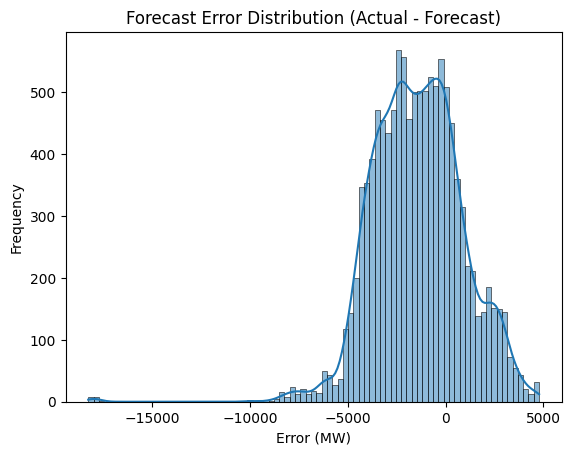

In [17]:
sns.histplot(basic_errors, kde=True)
plt.xlabel("Error (MW)")
plt.ylabel("Frequency")
plt.title("Forecast Error Distribution (Actual - Forecast)")
plt.show()

The histogram is scewed towards the left(negative) side. It means the model overestimated the wind power most of the time.

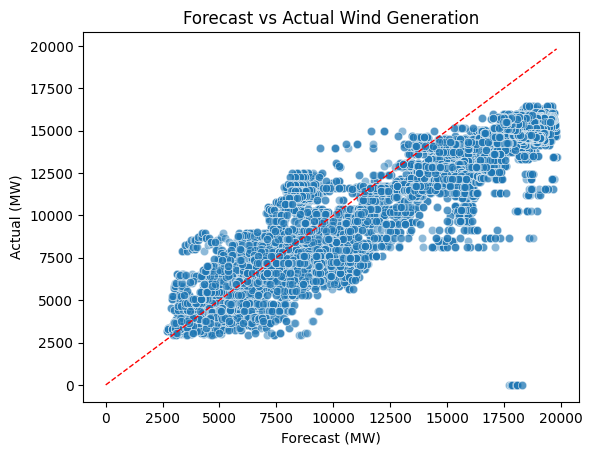

In [21]:
sns.scatterplot(data=df, x="forecast", y="actual", alpha=0.5)

# Plot x=y reference line across the data range
min_val = min(df["forecast"].min(), df["actual"].min())
max_val = max(df["forecast"].max(), df["actual"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)

plt.xlabel("Forecast (MW)")
plt.ylabel("Actual (MW)")
plt.title("Forecast vs Actual Wind Generation")
plt.show()

The plot shows a near line which means the forecast and actual wind power are close but still with lot of noises. There are times when the wind power was not generated at all and the system predicted the wind power which created the outliers on the bottom-right corner.

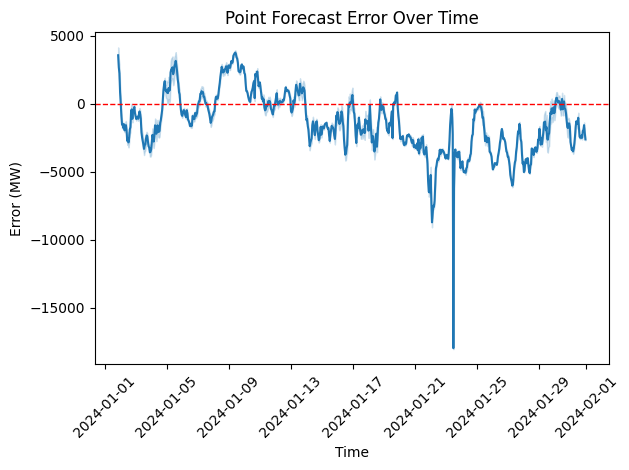

In [20]:
sns.lineplot(x=df["targetTime"], y=basic_errors)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Error (MW)")
plt.title("Point Forecast Error Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()